# Var

In [1]:
work_dir <- "/ebio/abt3_projects2/microc_metagenomics/out/MicroC_binning/mock/MQ_contigs"
samples <- c("MC1")

In [2]:
library(dplyr)
library(ggplot2)
library(LeyLabRMisc)
library(data.table)
library(tidyverse)
library(pROC)
library(PRROC)
library(ComplexHeatmap)
library(circlize)
library(Biostrings)
library(scales)


Attaching package: ‘dplyr’


The following objects are masked from ‘package:stats’:

    filter, lag


The following objects are masked from ‘package:base’:

    intersect, setdiff, setequal, union


Warning message:
“replacing previous import ‘data.table::last’ by ‘tidytable::last’ when loading ‘LeyLabRMisc’”
Warning message:
“replacing previous import ‘data.table::first’ by ‘tidytable::first’ when loading ‘LeyLabRMisc’”
Warning message:
“replacing previous import ‘data.table::between’ by ‘tidytable::between’ when loading ‘LeyLabRMisc’”
Warning message:
“replacing previous import ‘data.table::%notin%’ by ‘tidytable::%notin%’ when loading ‘LeyLabRMisc’”
Warning message:
“replacing previous import ‘data.table::fread’ by ‘tidytable::fread’ when loading ‘LeyLabRMisc’”
Warning message:
“replacing previous import ‘tidytable::fread’ by ‘data.table::fread’ when loading ‘LeyLabRMisc’”
Warning message:
“replacing previous import ‘tidytable::distinct’ by ‘dplyr::distinct’ when loading ‘LeyLabRM

In [3]:
# limit the size of output tables
df.dims(10)

# Load

In [4]:
# Load list with all the contacts between contigs (normalized intensities)
all_contacts <- fread(file.path(work_dir, "norm/Normalized_all_contacts_list.tsv"), sep = "\t")
#all_contacts <- fread(file.path(work_dir, "MC1_long_plasmids/norm/Normalized_contacts_filtered_list.tsv"), sep = "\t")
colnames(all_contacts) <- c("index1","index2","contacts")
all_contacts

index1,index2,contacts
<chr>,<chr>,<dbl>
contig_1,contig_2,651206.2
contig_1,contig_3,691715.0
contig_1,contig_4,455695.5
contig_1,contig_5,1693165.6
contig_1,contig_6,274590.6
⋮,⋮,⋮
contig_182,contig_186,0.000
contig_182,contig_187,101770.197
contig_183,contig_186,297.301


## Contig-bin association

In [5]:
# Load asociation of contigs to bins
bins <- fread(file.path(work_dir, "contig2bin.tsv"), sep = "\t", header = T)
bins

contig_id,original_sequence,Length
<chr>,<chr>,<int>
contig_1,B_fragilis_chr,209806
contig_2,B_fragilis_chr,12794
contig_3,B_fragilis_chr,27358
contig_4,B_fragilis_chr,16655
contig_5,B_fragilis_chr,462683
⋮,⋮,⋮
contig_183,C_aerofaciens_p2,1516
contig_184,P_nigrescens_p2,2697
contig_185,P_nigrescens_p4,3815


In [6]:
expected_links<- fread(file.path(work_dir, "expected_outcome.tsv"), sep = "\t", header = T)
expected_links

contig_id,bacterial_host
<chr>,<chr>
contig_21,B_fragilis_chr
contig_22,B_fragilis_chr
contig_23,B_fragilis_chr
contig_24,B_fragilis_chr
contig_25,B_fragilis_chr
⋮,⋮
contig_183,C_aerofaciens_chr
contig_184,P_nigrescens_chr
contig_185,P_nigrescens_chr


In [7]:
bin_sizes <- data.frame(bin = c("B_fragilis_chr", "B_fragilis_p1","P_nigrescens_chr1", "P_nigrescens_chr2", "P_nigrescens_p1", "P_nigrescens_p2", "P_nigrescens_p3", "P_nigrescens_p4", "C_aerofaciens_chr", "C_aerofaciens_p1", "C_aerofaciens_p2", "E_faecium_chr", "E_faecium_p1", "S_flexneri_chr", "S_flexneri_p1", "S_flexneri_p2", "S_flexneri_p3", "S_flexneri_p4"),
                        length = c(5205140, 36560, 567798, 2105254, 2630, 2697, 2697, 3815, 2428218, 23044, 4066, 2529607, 142622, 4659463, 113130, 165702, 4110, 3179))
bin_sizes

bin,length
<chr>,<dbl>
B_fragilis_chr,5205140
B_fragilis_p1,36560
P_nigrescens_chr1,567798
P_nigrescens_chr2,2105254
P_nigrescens_p1,2630
⋮,⋮
S_flexneri_chr,4659463
S_flexneri_p1,113130
S_flexneri_p2,165702


# Data processing

In [8]:
# Get the contig and bin association into the table with all the contacts
# Merge all_contacts with bins to get bin1
joined_contacts <- merge(all_contacts, bins, by.x = c("index1"), by.y = c("contig_id"), all.x = TRUE)
setnames(joined_contacts, "original_sequence", "bin1")
# Merge all_contacts with bins to get bin2
joined_contacts <- merge(joined_contacts, bins, by.x = c("index2"), by.y = c("contig_id"), all.x = TRUE)
setnames(joined_contacts, "original_sequence", "bin2")
# Reorder columns to desired order
joined_contacts <- joined_contacts[, .(index1, index2, contacts, bin1, bin2)]
joined_contacts

index1,index2,contacts,bin1,bin2
<chr>,<chr>,<dbl>,<chr>,<chr>
contig_1,contig_10,515182.0,B_fragilis_chr,B_fragilis_chr
contig_2,contig_10,113342.9,B_fragilis_chr,B_fragilis_chr
contig_3,contig_10,177304.7,B_fragilis_chr,B_fragilis_chr
contig_4,contig_10,137044.8,B_fragilis_chr,B_fragilis_chr
contig_5,contig_10,984646.1,B_fragilis_chr,B_fragilis_chr
⋮,⋮,⋮,⋮,⋮
contig_94,contig_99,198209.1,E_faecium_p1,E_faecium_p1
contig_95,contig_99,178145.1,E_faecium_p1,E_faecium_p1
contig_96,contig_99,108628.7,E_faecium_p1,E_faecium_p1


In [9]:
# Generate tables that contain contacts between the same MAG and different MAGs
all_contacts_no_NA <- joined_contacts[!(is.na(joined_contacts$bin1)|is.na(joined_contacts$bin2)),]
intra_contacts <- all_contacts_no_NA[all_contacts_no_NA$bin1 == all_contacts_no_NA$bin2,]
inter_contacts <- all_contacts_no_NA[all_contacts_no_NA$bin1 != all_contacts_no_NA$bin2,]
intra_contacts
inter_contacts

index1,index2,contacts,bin1,bin2
<chr>,<chr>,<dbl>,<chr>,<chr>
contig_1,contig_10,515182.0,B_fragilis_chr,B_fragilis_chr
contig_2,contig_10,113342.9,B_fragilis_chr,B_fragilis_chr
contig_3,contig_10,177304.7,B_fragilis_chr,B_fragilis_chr
contig_4,contig_10,137044.8,B_fragilis_chr,B_fragilis_chr
contig_5,contig_10,984646.1,B_fragilis_chr,B_fragilis_chr
⋮,⋮,⋮,⋮,⋮
contig_94,contig_99,198209.1,E_faecium_p1,E_faecium_p1
contig_95,contig_99,178145.1,E_faecium_p1,E_faecium_p1
contig_96,contig_99,108628.7,E_faecium_p1,E_faecium_p1


index1,index2,contacts,bin1,bin2
<chr>,<chr>,<dbl>,<chr>,<chr>
contig_1,contig_100,3137.935,B_fragilis_chr,E_faecium_p1
contig_10,contig_100,5216.717,B_fragilis_chr,E_faecium_p1
contig_11,contig_100,1082.415,B_fragilis_chr,E_faecium_p1
contig_12,contig_100,1924.993,B_fragilis_chr,E_faecium_p1
contig_13,contig_100,1467.601,B_fragilis_chr,E_faecium_p1
⋮,⋮,⋮,⋮,⋮
contig_9,contig_99,3020.031,B_fragilis_chr,E_faecium_p1
contig_90,contig_99,81986.715,E_faecium_chr,E_faecium_p1
contig_91,contig_99,70978.523,E_faecium_chr,E_faecium_p1


In [10]:
# Calculation of PR curves
# Convert Contact_Type to binary labels
combined_contacts_roc <- bind_rows(mutate(intra_contacts, Contact_Type = "within same MAG"),
                               mutate(inter_contacts, Contact_Type = "Between different MAGs"))
combined_contacts_roc$Contact_Label <- ifelse(combined_contacts_roc$Contact_Type == "within same MAG", 1, 0)

pr_list <- list()
threshold_list <- list()
auc_table <- data.frame(row.names = c("AUC Integral", "Random AUC"))

for (s in samples) {
  # Subset data by sample
  sample_data <- subset(combined_contacts_roc)#, sample == s)
  
  # Calculate the Precision-Recall curve
  pr_obj <- pr.curve(scores.class0 = sample_data$contacts, weights.class0 = sample_data$Contact_Label, curve = TRUE , 
  rand.compute = TRUE,  max.compute = TRUE, min.compute = TRUE)
  print(pr_obj)
  
  # Store the PR curve object
  pr_list[[s]] <- pr_obj
  
  # Extract precision, recall, and thresholds
  recalls <- pr_obj$curve[, 1]
  precisions <- pr_obj$curve[, 2]
  thresholds <- pr_obj$curve[, 3]
  
  # Calculate F1-score for each threshold
  f1_scores <- 2 * (precisions * recalls) / (precisions + recalls)

  optimal_index <- which.max(f1_scores)
  optimal_threshold <- median(thresholds[optimal_index])
  threshold_list[[s]] <- optimal_threshold
  
  # Add AUC integral and random AUC as a new column to the table
  auc_table[[s]] <- c(pr_obj$auc.integral, pr_obj$rand[2])

  # Print the optimal threshold and corresponding F1 score
  cat("\nOptimal Threshold for sample", s, ":", optimal_threshold, "\n")
  cat("F1 Score at Optimal Threshold:", f1_scores[optimal_index], "\n")
  cat("Recall at Optimal Threshold:", recalls[optimal_index], "\n")
  cat("Precision at Optimal Threshold:", precisions[optimal_index], "\n")

}


  Precision-recall curve

    Area under curve (Integral):
     0.8206727 

    Relative area under curve (Integral):
     0.8105604 

    Area under curve (Davis & Goadrich):
     0.8206727 

    Relative area under curves (Davis & Goadrich):
     0.8105603 

    Curve for scores from  0  to  2125380 
    ( can be plotted with plot(x) )



    Maximum AUC:
     1   1 


    Minimum AUC:
     0.05338042   0.05338042 


    AUC of a random classifier:
     0.1030282   0.1030282 

Optimal Threshold for sample MC1 : 72066.75 
F1 Score at Optimal Threshold: 0.739909 
Recall at Optimal Threshold: 0.8236486 
Precision at Optimal Threshold: 0.6716253 


In [11]:
threshold_list
auc_table

$MC1
[1] 72066.75

,MC1
,<named list>
AUC Integral,0.820672....
Random AUC,0.103028....


In [12]:
for (sample in names(auc_table)) {
  auc_integral <- as.numeric(auc_table[[sample]][1])
  random_auc   <- as.numeric(auc_table[[sample]][2])

  print(paste("The ratio for sample", sample, "is:", auc_integral/random_auc))
}

[1] "The ratio for sample MC1 is: 7.96551604694641"


## Plasmids

In [13]:
joined_contacts_plasmids <- joined_contacts %>%
  mutate(
    index1_is_plasmid = str_detect(bin1, "p\\d+$"),
    index2_is_plasmid = str_detect(bin2, "p\\d+$")
  )#%>% filter(contacts > threshold_list[[1]])
joined_contacts_plasmids

index1,index2,contacts,bin1,bin2,index1_is_plasmid,index2_is_plasmid
<chr>,<chr>,<dbl>,<chr>,<chr>,<lgl>,<lgl>
contig_1,contig_10,515182.0,B_fragilis_chr,B_fragilis_chr,FALSE,FALSE
contig_2,contig_10,113342.9,B_fragilis_chr,B_fragilis_chr,FALSE,FALSE
contig_3,contig_10,177304.7,B_fragilis_chr,B_fragilis_chr,FALSE,FALSE
contig_4,contig_10,137044.8,B_fragilis_chr,B_fragilis_chr,FALSE,FALSE
contig_5,contig_10,984646.1,B_fragilis_chr,B_fragilis_chr,FALSE,FALSE
⋮,⋮,⋮,⋮,⋮,⋮,⋮
contig_94,contig_99,198209.1,E_faecium_p1,E_faecium_p1,TRUE,TRUE
contig_95,contig_99,178145.1,E_faecium_p1,E_faecium_p1,TRUE,TRUE
contig_96,contig_99,108628.7,E_faecium_p1,E_faecium_p1,TRUE,TRUE


### Plasmid-plasmid contacts

In [14]:
p_p_contacts <- joined_contacts_plasmids %>%
  filter(index1_is_plasmid & index2_is_plasmid)
p_p_contacts

index1,index2,contacts,bin1,bin2,index1_is_plasmid,index2_is_plasmid
<chr>,<chr>,<dbl>,<chr>,<chr>,<lgl>,<lgl>
contig_94,contig_100,199266.43,E_faecium_p1,E_faecium_p1,TRUE,TRUE
contig_95,contig_100,150114.13,E_faecium_p1,E_faecium_p1,TRUE,TRUE
contig_96,contig_100,82775.84,E_faecium_p1,E_faecium_p1,TRUE,TRUE
contig_97,contig_100,181648.83,E_faecium_p1,E_faecium_p1,TRUE,TRUE
contig_98,contig_100,345638.29,E_faecium_p1,E_faecium_p1,TRUE,TRUE
⋮,⋮,⋮,⋮,⋮,⋮,⋮
contig_94,contig_99,198209.1,E_faecium_p1,E_faecium_p1,TRUE,TRUE
contig_95,contig_99,178145.1,E_faecium_p1,E_faecium_p1,TRUE,TRUE
contig_96,contig_99,108628.7,E_faecium_p1,E_faecium_p1,TRUE,TRUE


In [15]:
median_p_p_data <- p_p_contacts %>%
        group_by(index1, bin2) %>%
        summarize(median_contacts = median(contacts, na.rm = TRUE), .groups = 'drop') %>%
        arrange(desc(median_contacts))
median_p_p_data

index1,bin2,median_contacts
<chr>,<chr>,<dbl>
contig_111,E_faecium_p1,660984.6
contig_110,E_faecium_p1,518183.8
contig_161,S_flexneri_p2,414716.4
contig_144,S_flexneri_p1,371813.2
contig_160,S_flexneri_p2,286861.2
⋮,⋮,⋮
contig_97,S_flexneri_p4,0
contig_98,S_flexneri_p1,0
contig_98,S_flexneri_p2,0


In [16]:
median_p_p_data_checked <- median_p_p_data %>%
  filter(median_contacts > 0) %>%
  left_join(bins, by = c("index1" = "contig_id")) %>%
  mutate(check = ifelse(bin2 == original_sequence, TRUE, FALSE)) %>%
  select(-original_sequence)  # Remove the original_sequence column if you don't need it
median_p_p_data_checked

index1,bin2,median_contacts,Length,check
<chr>,<chr>,<dbl>,<int>,<lgl>
contig_111,E_faecium_p1,660984.6,1837,TRUE
contig_110,E_faecium_p1,518183.8,12965,TRUE
contig_161,S_flexneri_p2,414716.4,8270,TRUE
contig_144,S_flexneri_p1,371813.2,11764,TRUE
contig_160,S_flexneri_p2,286861.2,7530,TRUE
⋮,⋮,⋮,⋮,⋮
contig_111,C_aerofaciens_p1,281.153,1837,FALSE
contig_94,C_aerofaciens_p1,259.066,7987,FALSE
contig_97,C_aerofaciens_p2,256.636,4512,FALSE


In [17]:
median_p_p_data_checked$check

[1]  TRUE  TRUE  TRUE  TRUE  TRUE  TRUE  TRUE FALSE  TRUE  TRUE  TRUE  TRUE
 [13]  TRUE  TRUE  TRUE  TRUE  TRUE  TRUE  TRUE  TRUE  TRUE  TRUE  TRUE  TRUE
 [25]  TRUE  TRUE  TRUE  TRUE  TRUE  TRUE  TRUE  TRUE  TRUE  TRUE  TRUE  TRUE
 [37]  TRUE  TRUE  TRUE  TRUE  TRUE FALSE  TRUE  TRUE  TRUE  TRUE FALSE  TRUE
 [49] FALSE FALSE  TRUE FALSE  TRUE FALSE FALSE FALSE FALSE FALSE FALSE FALSE
 [61] FALSE FALSE FALSE FALSE FALSE FALSE FALSE FALSE FALSE FALSE FALSE FALSE
 [73] FALSE FALSE FALSE FALSE FALSE FALSE FALSE FALSE FALSE FALSE FALSE FALSE
 [85] FALSE FALSE FALSE FALSE FALSE FALSE FALSE FALSE FALSE FALSE FALSE FALSE
 [97] FALSE FALSE FALSE FALSE FALSE FALSE FALSE FALSE FALSE FALSE FALSE FALSE
[109] FALSE FALSE FALSE FALSE FALSE FALSE FALSE FALSE FALSE FALSE FALSE FALSE
[121] FALSE FALSE FALSE FALSE FALSE FALSE FALSE FALSE FALSE FALSE FALSE FALSE
[133] FALSE FALSE FALSE FALSE FALSE FALSE FALSE FALSE FALSE FALSE FALSE FALSE
[145] FALSE FALSE FALSE FALSE FALSE FALSE FALSE FALSE FALSE FALSE

### plasmid-MAG contacts

In [18]:
p_m_contacts <- joined_contacts_plasmids %>%
  filter(index1_is_plasmid | index2_is_plasmid) %>%
  filter(!(index1_is_plasmid & index2_is_plasmid))
p_m_contacts

index1,index2,contacts,bin1,bin2,index1_is_plasmid,index2_is_plasmid
<chr>,<chr>,<dbl>,<chr>,<chr>,<lgl>,<lgl>
contig_1,contig_100,3137.935,B_fragilis_chr,E_faecium_p1,FALSE,TRUE
contig_10,contig_100,5216.717,B_fragilis_chr,E_faecium_p1,FALSE,TRUE
contig_11,contig_100,1082.415,B_fragilis_chr,E_faecium_p1,FALSE,TRUE
contig_12,contig_100,1924.993,B_fragilis_chr,E_faecium_p1,FALSE,TRUE
contig_13,contig_100,1467.601,B_fragilis_chr,E_faecium_p1,FALSE,TRUE
⋮,⋮,⋮,⋮,⋮,⋮,⋮
contig_9,contig_99,3020.031,B_fragilis_chr,E_faecium_p1,FALSE,TRUE
contig_90,contig_99,81986.715,E_faecium_chr,E_faecium_p1,FALSE,TRUE
contig_91,contig_99,70978.523,E_faecium_chr,E_faecium_p1,FALSE,TRUE


In [19]:
rows_to_swap <- p_m_contacts$index1_is_plasmid == FALSE
p_m_contacts[rows_to_swap, c("index1", "index2")] <- p_m_contacts[rows_to_swap, c("index2", "index1")]
p_m_contacts[rows_to_swap, c("bin1", "bin2")] <- p_m_contacts[rows_to_swap, c("bin2", "bin1")]
p_m_contacts[rows_to_swap, c("index1_is_plasmid", "index2_is_plasmid")] <- p_m_contacts[rows_to_swap, c("index2_is_plasmid", "index1_is_plasmid")]
p_m_contacts

index1,index2,contacts,bin1,bin2,index1_is_plasmid,index2_is_plasmid
<chr>,<chr>,<dbl>,<chr>,<chr>,<lgl>,<lgl>
contig_100,contig_1,3137.935,E_faecium_p1,B_fragilis_chr,TRUE,FALSE
contig_100,contig_10,5216.717,E_faecium_p1,B_fragilis_chr,TRUE,FALSE
contig_100,contig_11,1082.415,E_faecium_p1,B_fragilis_chr,TRUE,FALSE
contig_100,contig_12,1924.993,E_faecium_p1,B_fragilis_chr,TRUE,FALSE
contig_100,contig_13,1467.601,E_faecium_p1,B_fragilis_chr,TRUE,FALSE
⋮,⋮,⋮,⋮,⋮,⋮,⋮
contig_99,contig_9,3020.031,E_faecium_p1,B_fragilis_chr,TRUE,FALSE
contig_99,contig_90,81986.715,E_faecium_p1,E_faecium_chr,TRUE,FALSE
contig_99,contig_91,70978.523,E_faecium_p1,E_faecium_chr,TRUE,FALSE


#### Median

In [20]:
median_p_m_data <- p_m_contacts %>%
        group_by(index1, bin2) %>%
        summarize(median_contacts = median(contacts, na.rm = TRUE), .groups = 'drop') %>%
        arrange(desc(median_contacts))
median_p_m_data

index1,bin2,median_contacts
<chr>,<chr>,<dbl>
contig_187,C_aerofaciens_chr,474560.5
contig_183,C_aerofaciens_chr,230257.9
contig_162,S_flexneri_chr,152266.9
contig_149,S_flexneri_chr,142425.0
contig_153,S_flexneri_chr,130648.5
⋮,⋮,⋮
contig_157,P_nigrescens_chr2,0
contig_158,P_nigrescens_chr1,0
contig_160,P_nigrescens_chr1,0


In [21]:
median_p_m_data_checked <- median_p_m_data %>%
  #filter(median_contacts > 0) %>%
  left_join(bins, by = c("index1" = "contig_id")) %>%
  mutate(
    # Extract the part before the first underscore (e.g., "S_flexneri" from "S_flexneri_chr")
    str_str_bin2 = strsplit(bin2, "_")[[1]][1],  # This is wrong — we need to split properly
    str_str_original = strsplit(original_sequence, "_")[[1]][1]
  ) %>%
  # Fix: use str_split_fixed or better, use stringr
  mutate(
    str_str_bin2 = str_split_fixed(bin2, "_", 2)[, 1],
    str_str_original = str_split_fixed(original_sequence, "_", 2)[, 1]
  ) %>%
  mutate(
    check = str_str_bin2 == str_str_original
  ) %>%
  select(-str_str_bin2, -str_str_original, -original_sequence)  # Remove helper columns
median_p_m_data_checked

index1,bin2,median_contacts,Length,check
<chr>,<chr>,<dbl>,<int>,<lgl>
contig_187,C_aerofaciens_chr,474560.5,23044,TRUE
contig_183,C_aerofaciens_chr,230257.9,1516,TRUE
contig_162,S_flexneri_chr,152266.9,22718,TRUE
contig_149,S_flexneri_chr,142425.0,22479,TRUE
contig_153,S_flexneri_chr,130648.5,20390,TRUE
⋮,⋮,⋮,⋮,⋮
contig_157,P_nigrescens_chr2,0,1606,FALSE
contig_158,P_nigrescens_chr1,0,6543,FALSE
contig_160,P_nigrescens_chr1,0,7530,FALSE


In [22]:
median_p_m_data_checked$check

[1]  TRUE  TRUE  TRUE  TRUE  TRUE  TRUE  TRUE  TRUE  TRUE  TRUE  TRUE  TRUE
 [13]  TRUE  TRUE  TRUE  TRUE  TRUE  TRUE  TRUE  TRUE  TRUE  TRUE  TRUE  TRUE
 [25]  TRUE  TRUE  TRUE  TRUE  TRUE  TRUE  TRUE  TRUE  TRUE  TRUE  TRUE  TRUE
 [37]  TRUE  TRUE  TRUE  TRUE  TRUE  TRUE  TRUE  TRUE  TRUE  TRUE  TRUE  TRUE
 [49]  TRUE  TRUE  TRUE  TRUE  TRUE FALSE FALSE FALSE FALSE FALSE FALSE FALSE
 [61] FALSE FALSE FALSE FALSE FALSE FALSE FALSE FALSE FALSE FALSE FALSE FALSE
 [73] FALSE FALSE FALSE FALSE FALSE FALSE FALSE FALSE FALSE FALSE FALSE FALSE
 [85] FALSE FALSE FALSE FALSE FALSE FALSE FALSE FALSE FALSE FALSE FALSE FALSE
 [97] FALSE FALSE FALSE FALSE FALSE FALSE FALSE FALSE FALSE FALSE FALSE FALSE
[109] FALSE FALSE FALSE FALSE FALSE FALSE FALSE FALSE FALSE FALSE FALSE FALSE
[121] FALSE FALSE FALSE FALSE FALSE FALSE FALSE FALSE FALSE FALSE FALSE FALSE
[133] FALSE FALSE FALSE FALSE FALSE FALSE FALSE FALSE FALSE FALSE FALSE FALSE
[145] FALSE FALSE FALSE FALSE FALSE FALSE FALSE FALSE FALSE FALSE FALSE FALSE
[157] FALSE FALSE FALSE FALSE FALSE FALSE FALSE FALSE FALSE FALSE FALSE FALSE
[169] FALSE FALSE FALSE FALSE FALSE FALSE FALSE FALSE FALSE FALSE FALSE FALSE
[181] FALSE FALSE FALSE FALSE FALSE FALSE FALSE FALSE FALSE FALSE FALSE FALSE
[193] FALSE FALSE FALSE FALSE FALSE FALSE FALSE FALSE FALSE FALSE FALSE FALSE
[205] FALSE FALSE FALSE FALSE FALSE FALSE FALSE FALSE FALSE FALSE FALSE FALSE
[217] FALSE FALSE FALSE FALSE FALSE FALSE FALSE FALSE FALSE FALSE FALSE FALSE
[229] FALSE FALSE FALSE FALSE FALSE FALSE FALSE FALSE FALSE FALSE FALSE FALSE
[241] FALSE FALSE FALSE FALSE FALSE FALSE FALSE FALSE FALSE FALSE FALSE FALSE
[253] FALSE FALSE FALSE FALSE FALSE FALSE FALSE FALSE FALSE FALSE FALSE FALSE
[265] FALSE FALSE FALSE FALSE FALSE FALSE FALSE FALSE FALSE FALSE FALSE FALSE
[277] FALSE FALSE FALSE FALSE FALSE FALSE FALSE FALSE FALSE FALSE FALSE FALSE
[289] FALSE FALSE FALSE FALSE FALSE FALSE FALSE FALSE FALSE FALSE FALSE FALSE
[301] FALSE FALSE FALSE FALSE FALSE FALSE FALSE FALSE FALSE FALSE FALSE FALSE
[313] FALSE FALSE FALSE FALSE FALSE FALSE

In [23]:
df.dims(18)
#Check which contigs are not in the obtained contacts
expected_links <- expected_links %>%
  mutate(
    in_index1 = contig_id %in% median_p_m_data_checked$index1
  )
  expected_links %>% filter(in_index1 == FALSE)

contig_id,bacterial_host,in_index1
<chr>,<chr>,<lgl>
contig_21,B_fragilis_chr,FALSE
contig_22,B_fragilis_chr,FALSE
contig_23,B_fragilis_chr,FALSE
contig_24,B_fragilis_chr,FALSE
contig_25,B_fragilis_chr,FALSE
contig_26,B_fragilis_chr,FALSE
contig_27,B_fragilis_chr,FALSE
contig_28,B_fragilis_chr,FALSE
contig_29,B_fragilis_chr,FALSE


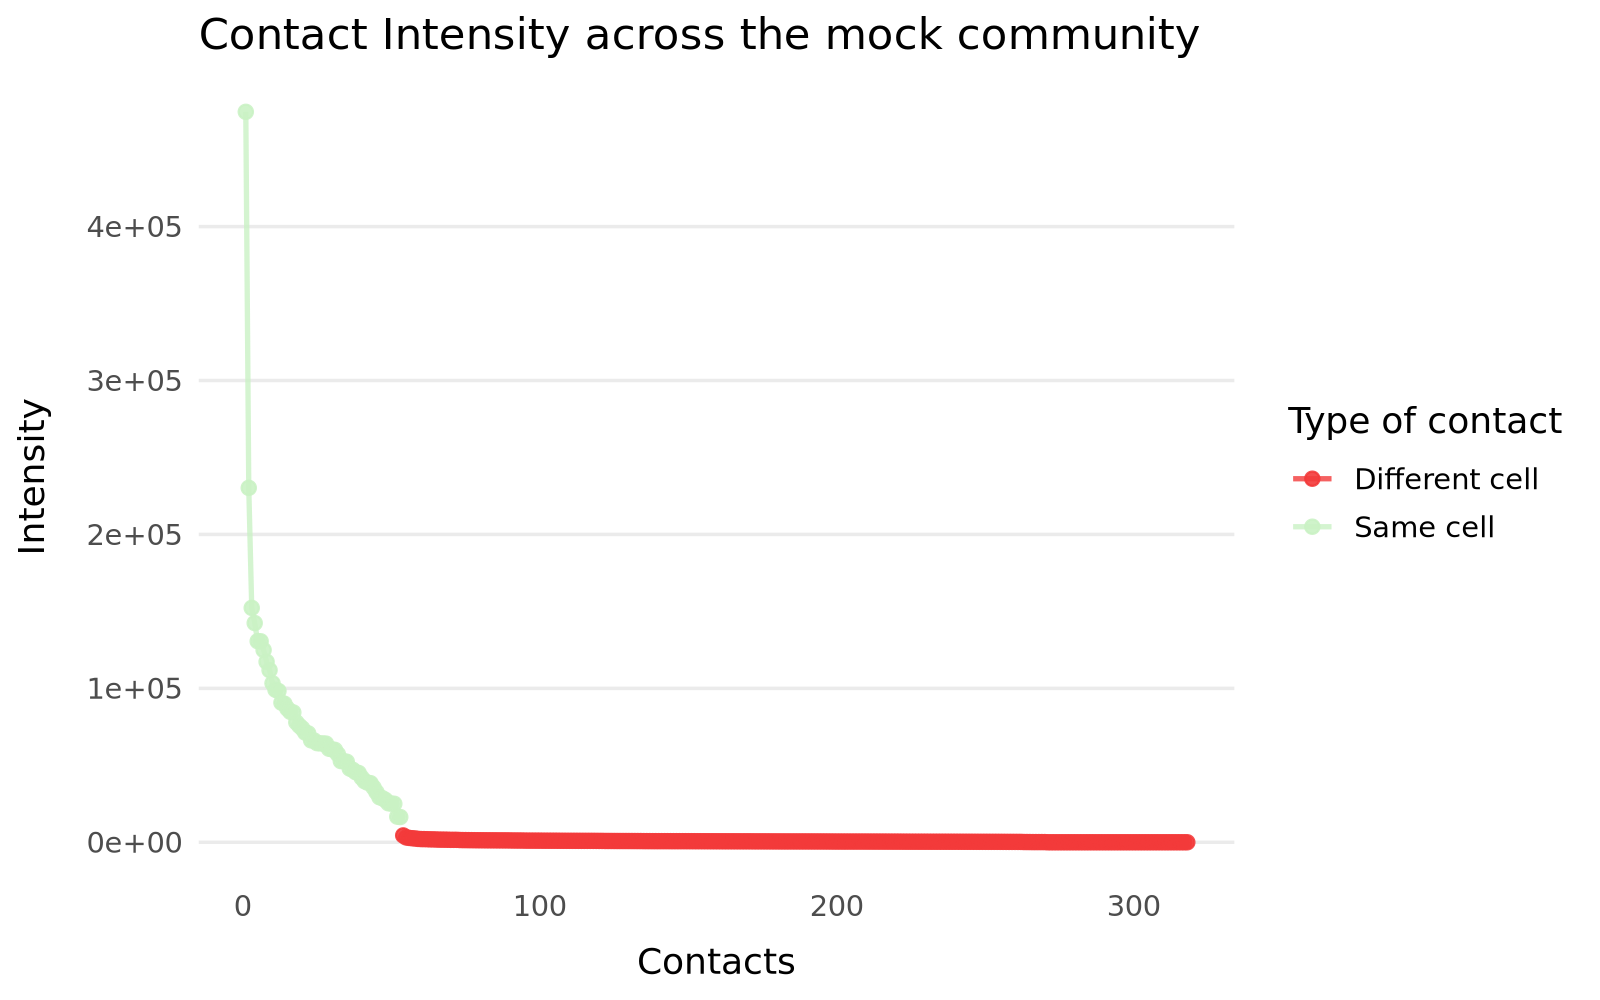

In [24]:
p.dims(8,5)
median_p_m_data_checked %>%
  mutate(
    x = seq_along(median_contacts)#,
  #  grp = cumsum(check != lag(check, default = first(check)))
  ) %>%
  ggplot(aes(
    x = x,
    y = median_contacts,
    color = check,
    group = check
  )) +
    geom_line(linewidth = 0.9, alpha = 0.8) +
  geom_point(size = 2, alpha = 0.9) +
  scale_color_manual(
    values = c(
      `TRUE` = "#c9f1c4",
      `FALSE`  = "#f23a3a"
    ),
    labels = c(
      `TRUE` = "Same cell",
      `FALSE`  = "Different cell"
    )
  ) +
  scale_y_continuous(
    labels = scales::label_scientific()
  ) +
  labs(
    title = "Contact Intensity across the mock community",
    x = "Contacts",
    y = "Intensity",
    color = "Type of contact"
  ) +
  theme_minimal(base_size = 13) +
  theme(
    panel.grid.minor = element_blank(),
    panel.grid.major.x = element_blank(),
    #legend.position = "top",
    #legend.direction = "horizontal",
    axis.title.x = element_text(margin = margin(t = 10)),
    axis.title.y = element_text(margin = margin(r = 12))
  )

#### Contact density (normalized by bin length)

In [25]:
df.dims(10)
contact_density <- p_m_contacts %>%
  group_by(index1, bin2) %>%
  summarize(
    sum_contacts = sum(contacts, na.rm = TRUE),
    .groups = "drop"
  ) %>%
  left_join(bin_sizes, by = c("bin2" = "bin")) %>%
  mutate(
    contact_density_per_base = sum_contacts / length,
    contact_density_per_kb   = contact_density_per_base * 1000
  ) %>%
  arrange(desc(contact_density_per_kb))

contact_density

index1,bin2,sum_contacts,length,contact_density_per_base,contact_density_per_kb
<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>
contig_187,C_aerofaciens_chr,8709341,2428218,3.5867210,3586.7210
contig_183,C_aerofaciens_chr,4366014,2428218,1.7980322,1798.0322
contig_100,E_faecium_chr,2615501,2529607,1.0339557,1033.9557
contig_110,E_faecium_chr,2444073,2529607,0.9661868,966.1868
contig_98,E_faecium_chr,2299419,2529607,0.9090024,909.0024
⋮,⋮,⋮,⋮,⋮,⋮
contig_134,B_fragilis_chr,4915.667,5205140,0.0009443871,0.9443871
contig_140,C_aerofaciens_chr,2220.751,2428218,0.0009145600,0.9145600
contig_145,E_faecium_chr,2036.128,2529607,0.0008049187,0.8049187


In [26]:
contact_density_checked <- contact_density %>%
  #filter(median_contacts > 0) %>%
  left_join(bins, by = c("index1" = "contig_id")) %>%
  mutate(
    # Extract the part before the first underscore (e.g., "S_flexneri" from "S_flexneri_chr")
    str_str_bin2 = strsplit(bin2, "_")[[1]][1],  # This is wrong — we need to split properly
    str_str_original = strsplit(original_sequence, "_")[[1]][1]
  ) %>%
  # Fix: use str_split_fixed or better, use stringr
  mutate(
    str_str_bin2 = str_split_fixed(bin2, "_", 2)[, 1],
    str_str_original = str_split_fixed(original_sequence, "_", 2)[, 1]
  ) %>%
  mutate(
    check = str_str_bin2 == str_str_original
  ) %>%
  select(-str_str_bin2, -str_str_original, -original_sequence)  # Remove helper columns
contact_density_checked

index1,bin2,sum_contacts,length,contact_density_per_base,contact_density_per_kb,Length,check
<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<int>,<lgl>
contig_187,C_aerofaciens_chr,8709341,2428218,3.5867210,3586.7210,23044,TRUE
contig_183,C_aerofaciens_chr,4366014,2428218,1.7980322,1798.0322,1516,TRUE
contig_100,E_faecium_chr,2615501,2529607,1.0339557,1033.9557,16992,TRUE
contig_110,E_faecium_chr,2444073,2529607,0.9661868,966.1868,12965,TRUE
contig_98,E_faecium_chr,2299419,2529607,0.9090024,909.0024,11435,TRUE
⋮,⋮,⋮,⋮,⋮,⋮,⋮,⋮
contig_134,B_fragilis_chr,4915.667,5205140,0.0009443871,0.9443871,1589,FALSE
contig_140,C_aerofaciens_chr,2220.751,2428218,0.0009145600,0.9145600,3225,FALSE
contig_145,E_faecium_chr,2036.128,2529607,0.0008049187,0.8049187,1491,FALSE


In [27]:
contact_density_checked$check

[1]  TRUE  TRUE  TRUE  TRUE  TRUE  TRUE  TRUE  TRUE  TRUE  TRUE  TRUE  TRUE
 [13]  TRUE  TRUE  TRUE  TRUE  TRUE  TRUE  TRUE  TRUE  TRUE  TRUE  TRUE  TRUE
 [25]  TRUE  TRUE  TRUE  TRUE  TRUE  TRUE  TRUE  TRUE  TRUE  TRUE  TRUE  TRUE
 [37]  TRUE  TRUE  TRUE  TRUE  TRUE  TRUE  TRUE  TRUE  TRUE  TRUE  TRUE  TRUE
 [49]  TRUE  TRUE  TRUE  TRUE  TRUE FALSE FALSE FALSE FALSE FALSE FALSE FALSE
 [61] FALSE FALSE FALSE FALSE FALSE FALSE FALSE FALSE FALSE FALSE FALSE FALSE
 [73] FALSE FALSE FALSE FALSE FALSE FALSE FALSE FALSE FALSE FALSE FALSE FALSE
 [85] FALSE FALSE FALSE FALSE FALSE FALSE FALSE FALSE FALSE FALSE FALSE FALSE
 [97] FALSE FALSE FALSE FALSE FALSE FALSE FALSE FALSE FALSE FALSE FALSE FALSE
[109] FALSE FALSE FALSE FALSE FALSE FALSE FALSE FALSE FALSE FALSE FALSE FALSE
[121] FALSE FALSE FALSE FALSE FALSE FALSE FALSE FALSE FALSE FALSE FALSE FALSE
[133] FALSE FALSE FALSE FALSE FALSE FALSE FALSE FALSE FALSE FALSE FALSE FALSE
[145] FALSE FALSE FALSE FALSE FALSE FALSE FALSE FALSE FALSE FALSE FALSE FALSE
[157] FALSE FALSE FALSE FALSE FALSE FALSE FALSE FALSE FALSE FALSE FALSE FALSE
[169] FALSE FALSE FALSE FALSE FALSE FALSE FALSE FALSE FALSE FALSE FALSE FALSE
[181] FALSE FALSE FALSE FALSE FALSE FALSE FALSE FALSE FALSE FALSE FALSE FALSE
[193] FALSE FALSE FALSE FALSE FALSE FALSE FALSE FALSE FALSE FALSE FALSE FALSE
[205] FALSE FALSE FALSE FALSE FALSE FALSE FALSE FALSE FALSE FALSE FALSE FALSE
[217] FALSE FALSE FALSE FALSE FALSE FALSE FALSE FALSE FALSE FALSE FALSE FALSE
[229] FALSE FALSE FALSE FALSE FALSE FALSE FALSE FALSE FALSE FALSE FALSE FALSE
[241] FALSE FALSE FALSE FALSE FALSE FALSE FALSE FALSE FALSE FALSE FALSE FALSE
[253] FALSE FALSE FALSE FALSE FALSE FALSE FALSE FALSE FALSE FALSE FALSE FALSE
[265] FALSE FALSE FALSE FALSE FALSE FALSE FALSE FALSE FALSE FALSE FALSE FALSE
[277] FALSE FALSE FALSE FALSE FALSE FALSE FALSE FALSE FALSE FALSE FALSE FALSE
[289] FALSE FALSE FALSE FALSE FALSE FALSE FALSE FALSE FALSE FALSE FALSE FALSE
[301] FALSE FALSE FALSE FALSE FALSE FALSE FALSE FALSE FALSE FALSE FALSE FALSE
[313] FALSE FALSE FALSE FALSE FALSE FALSE

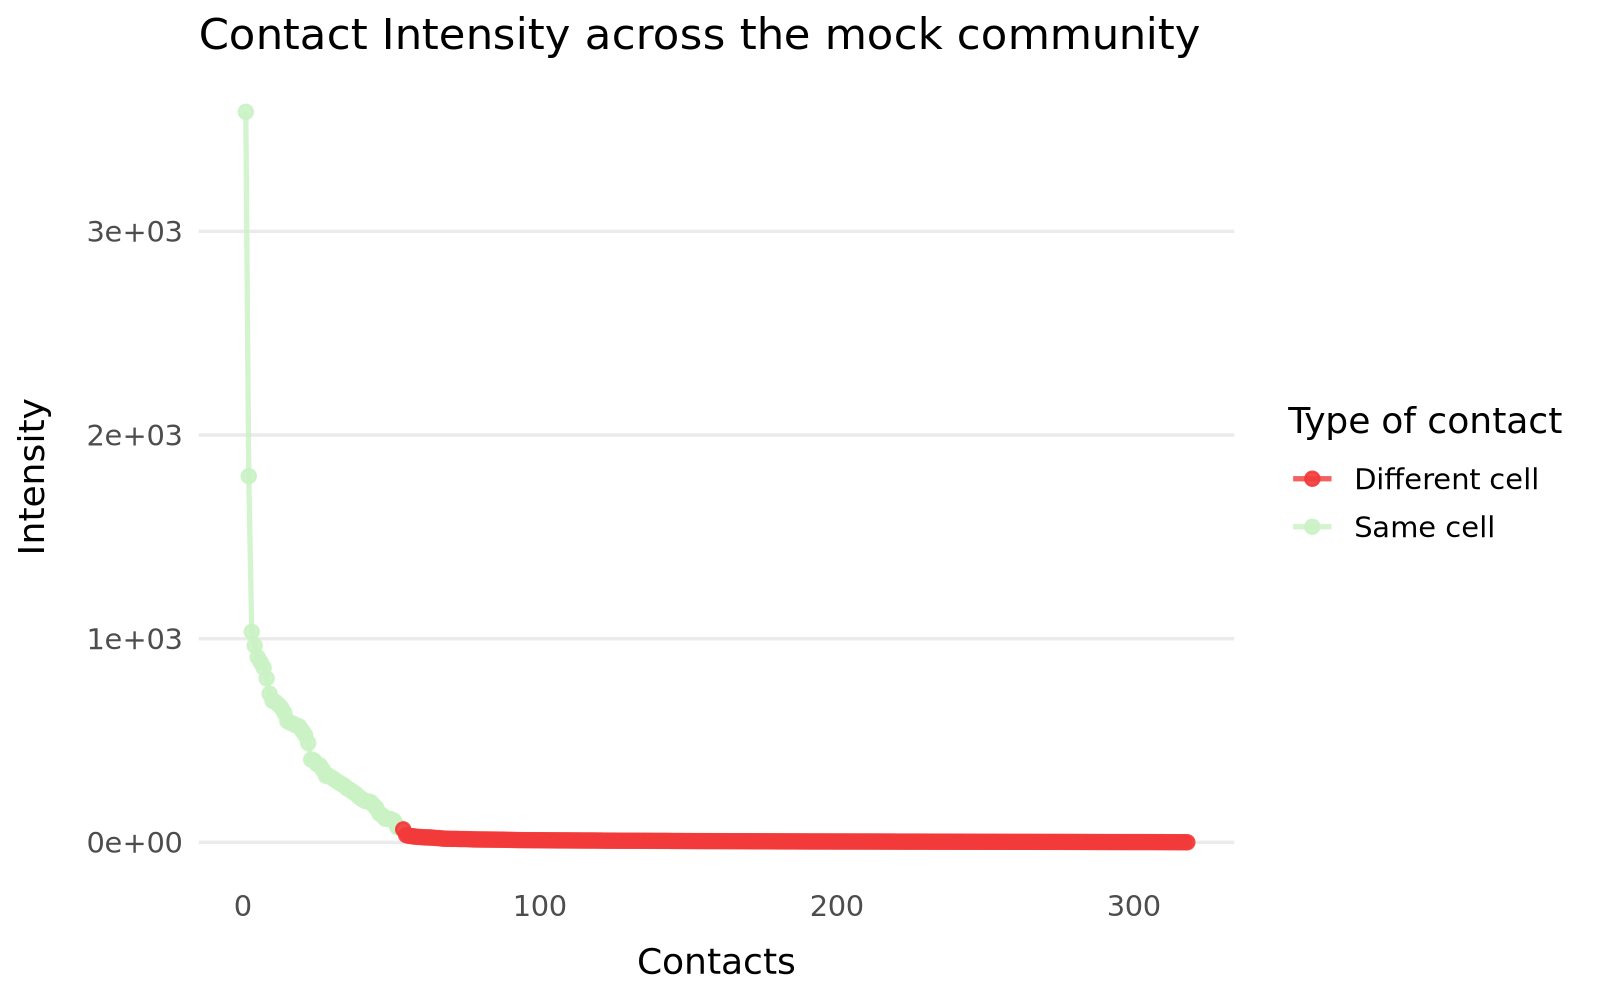

In [28]:
p.dims(8,5)
contact_density_checked %>%
  mutate(
    x = seq_along(contact_density_per_kb)#,
  #  grp = cumsum(check != lag(check, default = first(check)))
  ) %>%
  ggplot(aes(
    x = x,
    y = contact_density_per_kb,
    color = check,
    group = check
  )) +
    geom_line(linewidth = 0.9, alpha = 0.8) +
  geom_point(size = 2, alpha = 0.9) +
  scale_color_manual(
    values = c(
      `TRUE` = "#c9f1c4",
      `FALSE`  = "#f23a3a"
    ),
    labels = c(
      `TRUE` = "Same cell",
      `FALSE`  = "Different cell"
    )
  ) +
  scale_y_continuous(
    labels = scales::label_scientific()
  ) +
  labs(
    title = "Contact Intensity across the mock community",
    x = "Contacts",
    y = "Intensity",
    color = "Type of contact"
  ) +
  theme_minimal(base_size = 13) +
  theme(
    panel.grid.minor = element_blank(),
    panel.grid.major.x = element_blank(),
    #legend.position = "top",
    #legend.direction = "horizontal",
    axis.title.x = element_text(margin = margin(t = 10)),
    axis.title.y = element_text(margin = margin(r = 12))
  )

#### TD-IDF

In [29]:
# Total number of bins
N_bins <- nrow(bin_sizes)

# IDF: how many bins does each plasmid contig contact?
idf <- p_m_contacts %>%
  group_by(index1) %>%
  summarize(
    n_bins_contacted = n_distinct(bin2),
    .groups = "drop"
  ) %>%
  mutate(idf = log(N_bins / n_bins_contacted))

# TF: sum of contacts normalized by bin length
tf <- p_m_contacts %>%
  group_by(index1, bin2) %>%
  summarize(
    sum_contacts = sum(contacts, na.rm = TRUE),
    .groups = "drop"
  ) %>%
  left_join(bin_sizes, by = c("bin2" = "bin")) %>%
  mutate(tf = sum_contacts / length)

# TF-IDF
tfidf <- tf %>%
  left_join(idf, by = "index1") %>%
  mutate(tfidf = tf * idf) %>%
  arrange(desc(tfidf))

tfidf

index1,bin2,sum_contacts,length,tf,n_bins_contacted,idf,tfidf
<chr>,<chr>,<dbl>,<dbl>,<dbl>,<int>,<dbl>,<dbl>
contig_187,C_aerofaciens_chr,8709341,2428218,3.5867210,6,1.098612,3.9404158
contig_183,C_aerofaciens_chr,4366014,2428218,1.7980322,6,1.098612,1.9753403
contig_100,E_faecium_chr,2615501,2529607,1.0339557,6,1.098612,1.1359164
contig_110,E_faecium_chr,2444073,2529607,0.9661868,6,1.098612,1.0614647
contig_98,E_faecium_chr,2299419,2529607,0.9090024,6,1.098612,0.9986412
⋮,⋮,⋮,⋮,⋮,⋮,⋮,⋮
contig_134,B_fragilis_chr,4915.667,5205140,0.0009443871,6,1.098612,0.0010375153
contig_140,C_aerofaciens_chr,2220.751,2428218,0.0009145600,6,1.098612,0.0010047468
contig_145,E_faecium_chr,2036.128,2529607,0.0008049187,6,1.098612,0.0008842936


In [30]:
tfidf_checked <- tfidf %>%
  #filter(median_contacts > 0) %>%
  left_join(bins, by = c("index1" = "contig_id")) %>%
  mutate(
    # Extract the part before the first underscore (e.g., "S_flexneri" from "S_flexneri_chr")
    str_str_bin2 = strsplit(bin2, "_")[[1]][1],  # This is wrong — we need to split properly
    str_str_original = strsplit(original_sequence, "_")[[1]][1]
  ) %>%
  # Fix: use str_split_fixed or better, use stringr
  mutate(
    str_str_bin2 = str_split_fixed(bin2, "_", 2)[, 1],
    str_str_original = str_split_fixed(original_sequence, "_", 2)[, 1]
  ) %>%
  mutate(
    check = str_str_bin2 == str_str_original
  ) %>%
  select(-str_str_bin2, -str_str_original, -original_sequence)  # Remove helper columns
tfidf_checked

index1,bin2,sum_contacts,length,tf,n_bins_contacted,idf,tfidf,Length,check
<chr>,<chr>,<dbl>,<dbl>,<dbl>,<int>,<dbl>,<dbl>,<int>,<lgl>
contig_187,C_aerofaciens_chr,8709341,2428218,3.5867210,6,1.098612,3.9404158,23044,TRUE
contig_183,C_aerofaciens_chr,4366014,2428218,1.7980322,6,1.098612,1.9753403,1516,TRUE
contig_100,E_faecium_chr,2615501,2529607,1.0339557,6,1.098612,1.1359164,16992,TRUE
contig_110,E_faecium_chr,2444073,2529607,0.9661868,6,1.098612,1.0614647,12965,TRUE
contig_98,E_faecium_chr,2299419,2529607,0.9090024,6,1.098612,0.9986412,11435,TRUE
⋮,⋮,⋮,⋮,⋮,⋮,⋮,⋮,⋮,⋮
contig_134,B_fragilis_chr,4915.667,5205140,0.0009443871,6,1.098612,0.0010375153,1589,FALSE
contig_140,C_aerofaciens_chr,2220.751,2428218,0.0009145600,6,1.098612,0.0010047468,3225,FALSE
contig_145,E_faecium_chr,2036.128,2529607,0.0008049187,6,1.098612,0.0008842936,1491,FALSE


In [31]:
tfidf_checked$check

[1]  TRUE  TRUE  TRUE  TRUE  TRUE  TRUE  TRUE  TRUE  TRUE  TRUE  TRUE  TRUE
 [13]  TRUE  TRUE  TRUE  TRUE  TRUE  TRUE  TRUE  TRUE  TRUE  TRUE  TRUE  TRUE
 [25]  TRUE  TRUE  TRUE  TRUE  TRUE  TRUE  TRUE  TRUE  TRUE  TRUE  TRUE  TRUE
 [37]  TRUE  TRUE  TRUE  TRUE  TRUE  TRUE  TRUE  TRUE  TRUE  TRUE  TRUE  TRUE
 [49]  TRUE  TRUE  TRUE  TRUE  TRUE FALSE FALSE FALSE FALSE FALSE FALSE FALSE
 [61] FALSE FALSE FALSE FALSE FALSE FALSE FALSE FALSE FALSE FALSE FALSE FALSE
 [73] FALSE FALSE FALSE FALSE FALSE FALSE FALSE FALSE FALSE FALSE FALSE FALSE
 [85] FALSE FALSE FALSE FALSE FALSE FALSE FALSE FALSE FALSE FALSE FALSE FALSE
 [97] FALSE FALSE FALSE FALSE FALSE FALSE FALSE FALSE FALSE FALSE FALSE FALSE
[109] FALSE FALSE FALSE FALSE FALSE FALSE FALSE FALSE FALSE FALSE FALSE FALSE
[121] FALSE FALSE FALSE FALSE FALSE FALSE FALSE FALSE FALSE FALSE FALSE FALSE
[133] FALSE FALSE FALSE FALSE FALSE FALSE FALSE FALSE FALSE FALSE FALSE FALSE
[145] FALSE FALSE FALSE FALSE FALSE FALSE FALSE FALSE FALSE FALSE FALSE FALSE
[157] FALSE FALSE FALSE FALSE FALSE FALSE FALSE FALSE FALSE FALSE FALSE FALSE
[169] FALSE FALSE FALSE FALSE FALSE FALSE FALSE FALSE FALSE FALSE FALSE FALSE
[181] FALSE FALSE FALSE FALSE FALSE FALSE FALSE FALSE FALSE FALSE FALSE FALSE
[193] FALSE FALSE FALSE FALSE FALSE FALSE FALSE FALSE FALSE FALSE FALSE FALSE
[205] FALSE FALSE FALSE FALSE FALSE FALSE FALSE FALSE FALSE FALSE FALSE FALSE
[217] FALSE FALSE FALSE FALSE FALSE FALSE FALSE FALSE FALSE FALSE FALSE FALSE
[229] FALSE FALSE FALSE FALSE FALSE FALSE FALSE FALSE FALSE FALSE FALSE FALSE
[241] FALSE FALSE FALSE FALSE FALSE FALSE FALSE FALSE FALSE FALSE FALSE FALSE
[253] FALSE FALSE FALSE FALSE FALSE FALSE FALSE FALSE FALSE FALSE FALSE FALSE
[265] FALSE FALSE FALSE FALSE FALSE FALSE FALSE FALSE FALSE FALSE FALSE FALSE
[277] FALSE FALSE FALSE FALSE FALSE FALSE FALSE FALSE FALSE FALSE FALSE FALSE
[289] FALSE FALSE FALSE FALSE FALSE FALSE FALSE FALSE FALSE FALSE FALSE FALSE
[301] FALSE FALSE FALSE FALSE FALSE FALSE FALSE FALSE FALSE FALSE FALSE FALSE
[313] FALSE FALSE FALSE FALSE FALSE FALSE

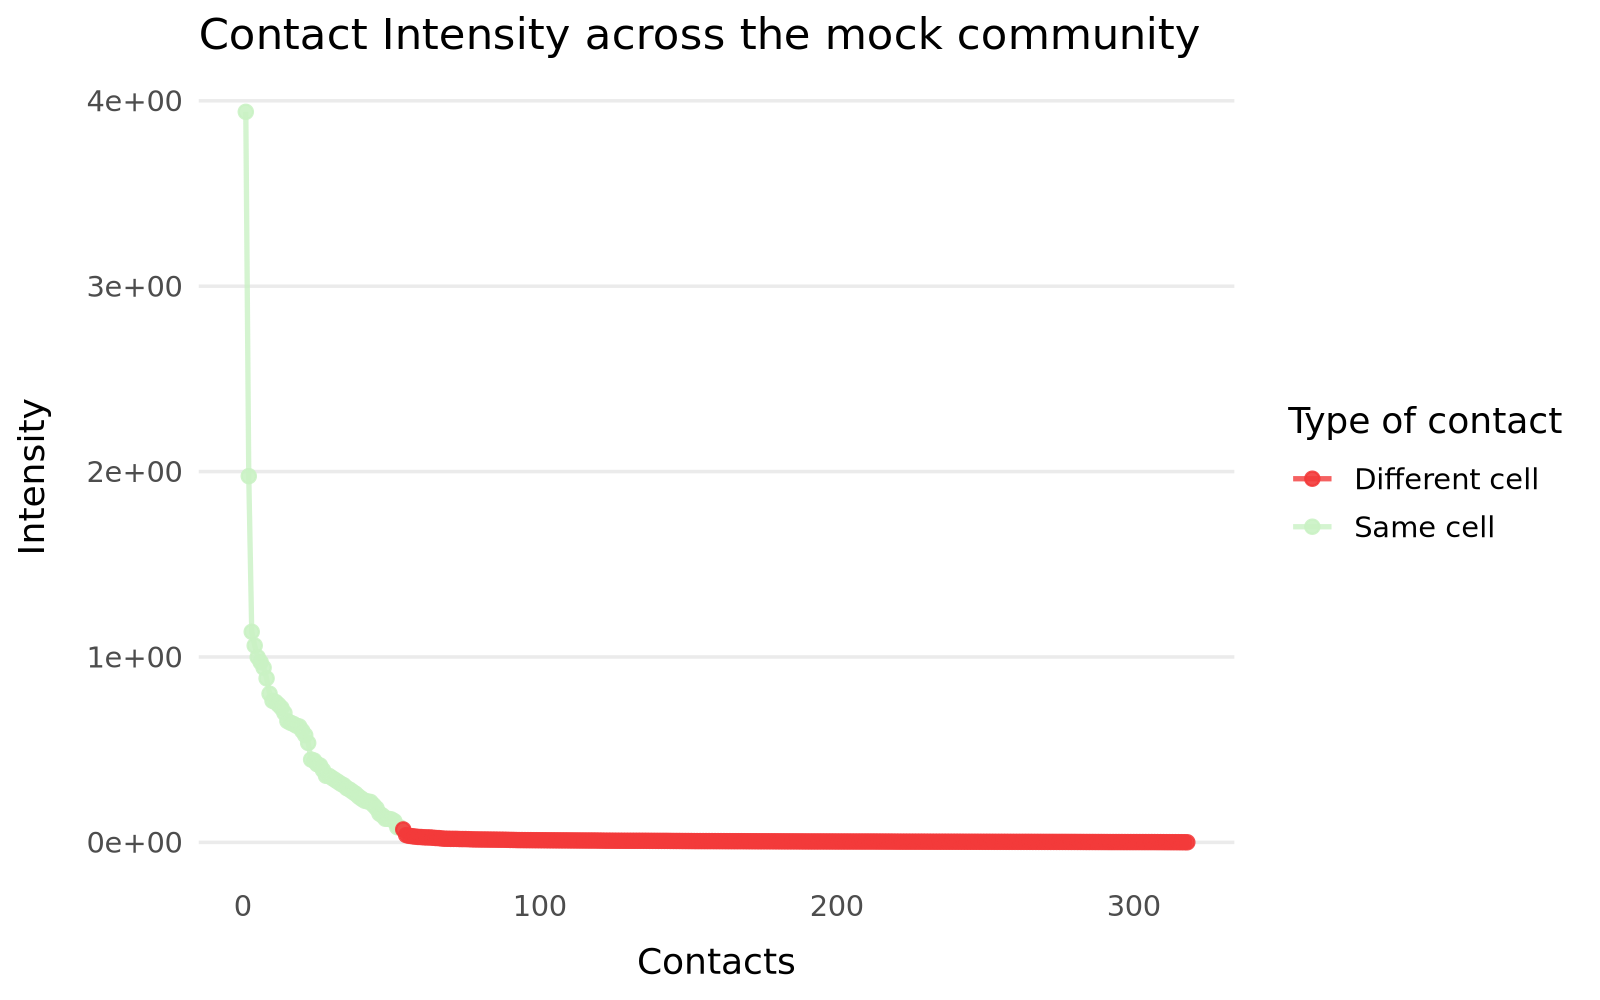

In [32]:
p.dims(8,5)
tfidf_checked %>%
  mutate(
    x = seq_along(tfidf)#,
  #  grp = cumsum(check != lag(check, default = first(check)))
  ) %>%
  ggplot(aes(
    x = x,
    y = tfidf,
    color = check,
    group = check
  )) +
    geom_line(linewidth = 0.9, alpha = 0.8) +
  geom_point(size = 2, alpha = 0.9) +
  scale_color_manual(
    values = c(
      `TRUE` = "#c9f1c4",
      `FALSE`  = "#f23a3a"
    ),
    labels = c(
      `TRUE` = "Same cell",
      `FALSE`  = "Different cell"
    )
  ) +
  scale_y_continuous(
    labels = scales::label_scientific()
  ) +
  labs(
    title = "Contact Intensity across the mock community",
    x = "Contacts",
    y = "Intensity",
    color = "Type of contact"
  ) +
  theme_minimal(base_size = 13) +
  theme(
    panel.grid.minor = element_blank(),
    panel.grid.major.x = element_blank(),
    #legend.position = "top",
    #legend.direction = "horizontal",
    axis.title.x = element_text(margin = margin(t = 10)),
    axis.title.y = element_text(margin = margin(r = 12))
  )

#### Geometry mean

In [33]:
geomean_density <- p_m_contacts %>%
  group_by(index1, bin2) %>%
  summarize(
    geom_mean_contacts = exp(mean(log(contacts), na.rm = TRUE)),  # geometric mean
    n_contigs = n(),
    .groups = "drop"
  ) %>%
  left_join(bin_sizes, by = c("bin2" = "bin")) %>%
  mutate(
    geomean_per_kb = (geom_mean_contacts / length) * 1000
  ) %>%
  arrange(desc(geomean_per_kb))

geomean_density

index1,bin2,geom_mean_contacts,n_contigs,length,geomean_per_kb
<chr>,<chr>,<dbl>,<int>,<dbl>,<dbl>
contig_187,C_aerofaciens_chr,362963.92,20,2428218,149.47749
contig_183,C_aerofaciens_chr,181944.96,20,2428218,74.92942
contig_100,E_faecium_chr,97783.83,20,2529607,38.65574
contig_110,E_faecium_chr,89654.97,20,2529607,35.44225
contig_98,E_faecium_chr,85451.35,20,2529607,33.78049
⋮,⋮,⋮,⋮,⋮,⋮
contig_98,P_nigrescens_chr2,0,20,2105254,0
contig_98,S_flexneri_chr,0,19,4659463,0
contig_99,P_nigrescens_chr1,0,18,567798,0


In [34]:
geomean_density_checked <- geomean_density %>%
  #filter(median_contacts > 0) %>%
  left_join(bins, by = c("index1" = "contig_id")) %>%
  mutate(
    # Extract the part before the first underscore (e.g., "S_flexneri" from "S_flexneri_chr")
    str_str_bin2 = strsplit(bin2, "_")[[1]][1],  # This is wrong — we need to split properly
    str_str_original = strsplit(original_sequence, "_")[[1]][1]
  ) %>%
  # Fix: use str_split_fixed or better, use stringr
  mutate(
    str_str_bin2 = str_split_fixed(bin2, "_", 2)[, 1],
    str_str_original = str_split_fixed(original_sequence, "_", 2)[, 1]
  ) %>%
  mutate(
    check = str_str_bin2 == str_str_original
  ) %>%
  select(-str_str_bin2, -str_str_original, -original_sequence)  # Remove helper columns
geomean_density_checked

index1,bin2,geom_mean_contacts,n_contigs,length,geomean_per_kb,Length,check
<chr>,<chr>,<dbl>,<int>,<dbl>,<dbl>,<int>,<lgl>
contig_187,C_aerofaciens_chr,362963.92,20,2428218,149.47749,23044,TRUE
contig_183,C_aerofaciens_chr,181944.96,20,2428218,74.92942,1516,TRUE
contig_100,E_faecium_chr,97783.83,20,2529607,38.65574,16992,TRUE
contig_110,E_faecium_chr,89654.97,20,2529607,35.44225,12965,TRUE
contig_98,E_faecium_chr,85451.35,20,2529607,33.78049,11435,TRUE
⋮,⋮,⋮,⋮,⋮,⋮,⋮,⋮
contig_98,P_nigrescens_chr2,0,20,2105254,0,11435,FALSE
contig_98,S_flexneri_chr,0,19,4659463,0,11435,FALSE
contig_99,P_nigrescens_chr1,0,18,567798,0,11493,FALSE


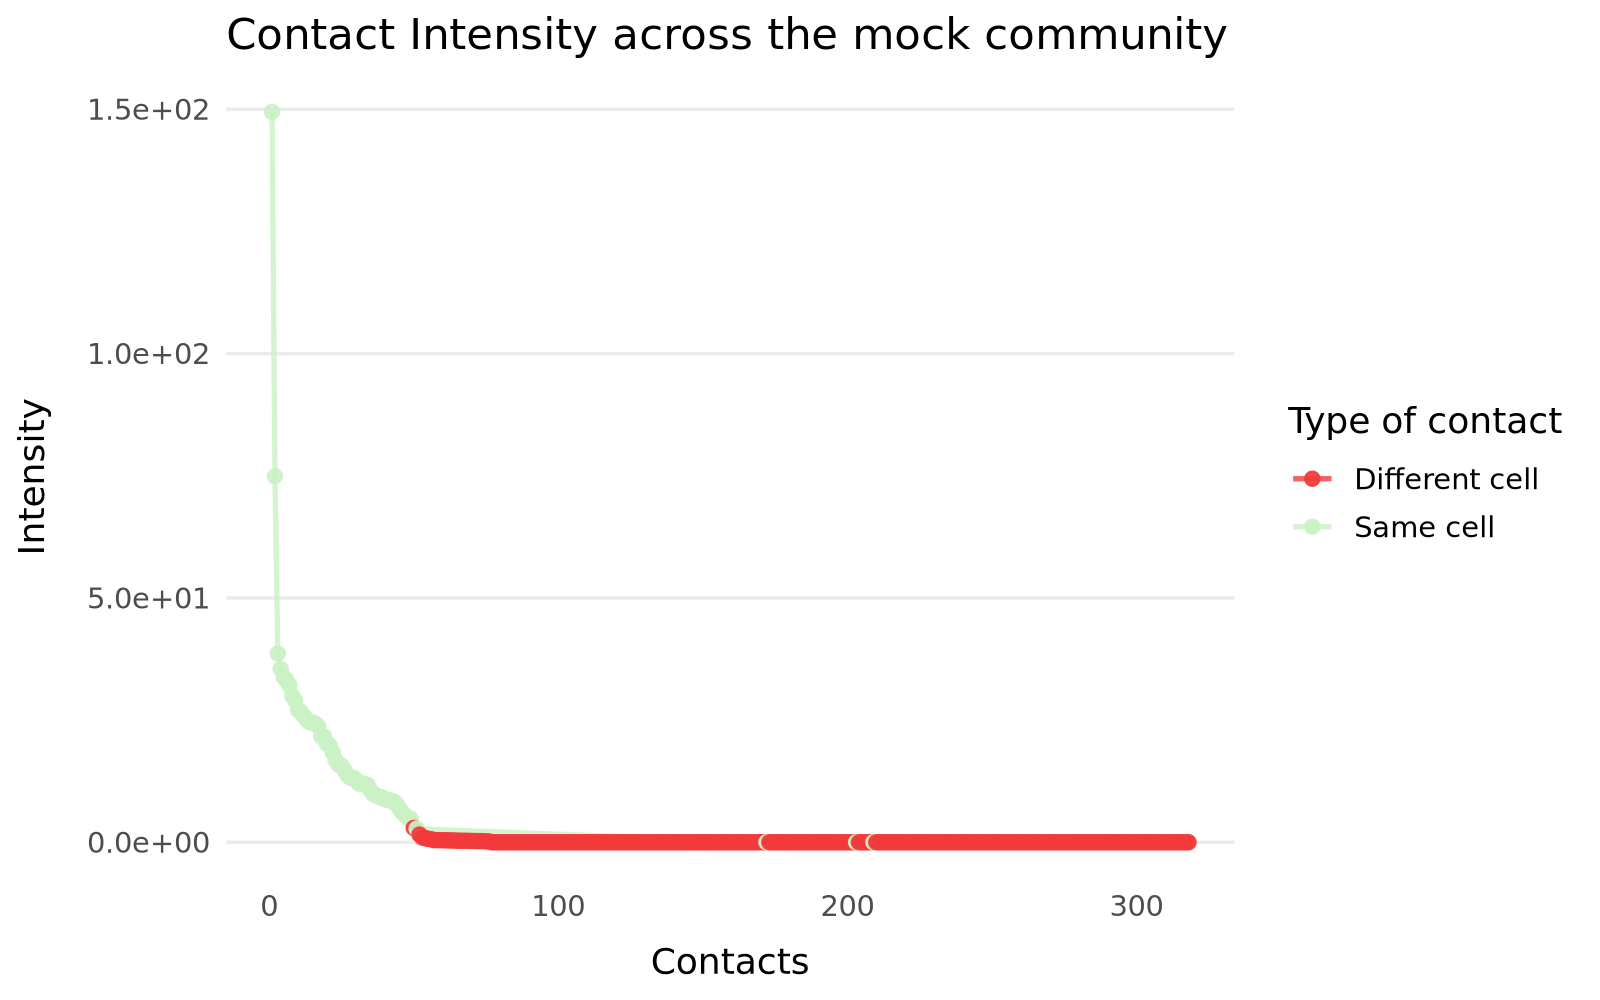

In [35]:
p.dims(8,5)
geomean_density_checked %>%
  mutate(
    x = seq_along(geomean_per_kb)#,
  #  grp = cumsum(check != lag(check, default = first(check)))
  ) %>%
  ggplot(aes(
    x = x,
    y = geomean_per_kb,
    color = check,
    group = check
  )) +
    geom_line(linewidth = 0.9, alpha = 0.8) +
  geom_point(size = 2, alpha = 0.9) +
  scale_color_manual(
    values = c(
      `TRUE` = "#c9f1c4",
      `FALSE`  = "#f23a3a"
    ),
    labels = c(
      `TRUE` = "Same cell",
      `FALSE`  = "Different cell"
    )
  ) +
  scale_y_continuous(
    labels = scales::label_scientific()
  ) +
  labs(
    title = "Contact Intensity across the mock community",
    x = "Contacts",
    y = "Intensity",
    color = "Type of contact"
  ) +
  theme_minimal(base_size = 13) +
  theme(
    panel.grid.minor = element_blank(),
    panel.grid.major.x = element_blank(),
    #legend.position = "top",
    #legend.direction = "horizontal",
    axis.title.x = element_text(margin = margin(t = 10)),
    axis.title.y = element_text(margin = margin(r = 12))
  )

In [36]:
geomean_density_checked$check

[1]  TRUE  TRUE  TRUE  TRUE  TRUE  TRUE  TRUE  TRUE  TRUE  TRUE  TRUE  TRUE
 [13]  TRUE  TRUE  TRUE  TRUE  TRUE  TRUE  TRUE  TRUE  TRUE  TRUE  TRUE  TRUE
 [25]  TRUE  TRUE  TRUE  TRUE  TRUE  TRUE  TRUE  TRUE  TRUE  TRUE  TRUE  TRUE
 [37]  TRUE  TRUE  TRUE  TRUE  TRUE  TRUE  TRUE  TRUE  TRUE  TRUE  TRUE  TRUE
 [49]  TRUE FALSE  TRUE FALSE FALSE FALSE FALSE FALSE FALSE FALSE FALSE FALSE
 [61] FALSE FALSE FALSE FALSE FALSE FALSE FALSE FALSE FALSE FALSE FALSE FALSE
 [73] FALSE FALSE FALSE FALSE FALSE FALSE FALSE FALSE FALSE FALSE FALSE FALSE
 [85] FALSE FALSE FALSE FALSE FALSE FALSE FALSE FALSE FALSE FALSE FALSE FALSE
 [97] FALSE FALSE FALSE FALSE FALSE FALSE FALSE FALSE FALSE FALSE FALSE FALSE
[109] FALSE FALSE FALSE FALSE FALSE FALSE FALSE FALSE FALSE FALSE FALSE FALSE
[121] FALSE FALSE FALSE FALSE FALSE FALSE FALSE FALSE FALSE FALSE FALSE FALSE
[133] FALSE FALSE FALSE FALSE FALSE FALSE FALSE FALSE FALSE FALSE FALSE FALSE
[145] FALSE FALSE FALSE FALSE FALSE FALSE FALSE FALSE FALSE FALSE FALSE FALSE
[157] FALSE FALSE FALSE FALSE FALSE FALSE FALSE FALSE FALSE FALSE FALSE FALSE
[169] FALSE FALSE FALSE  TRUE FALSE FALSE FALSE FALSE FALSE FALSE FALSE FALSE
[181] FALSE FALSE FALSE FALSE FALSE FALSE FALSE FALSE FALSE FALSE FALSE FALSE
[193] FALSE FALSE FALSE FALSE FALSE FALSE FALSE FALSE FALSE FALSE  TRUE FALSE
[205] FALSE FALSE FALSE FALSE  TRUE FALSE FALSE FALSE FALSE FALSE FALSE FALSE
[217] FALSE FALSE FALSE FALSE FALSE FALSE FALSE FALSE FALSE FALSE FALSE FALSE
[229] FALSE FALSE FALSE FALSE FALSE FALSE FALSE FALSE FALSE FALSE FALSE FALSE
[241] FALSE FALSE FALSE FALSE FALSE FALSE FALSE FALSE FALSE FALSE FALSE FALSE
[253] FALSE FALSE FALSE FALSE FALSE FALSE FALSE FALSE FALSE FALSE FALSE FALSE
[265] FALSE FALSE FALSE FALSE FALSE FALSE FALSE FALSE FALSE FALSE FALSE FALSE
[277] FALSE FALSE FALSE FALSE FALSE FALSE FALSE FALSE FALSE FALSE FALSE FALSE
[289] FALSE FALSE FALSE FALSE FALSE FALSE FALSE FALSE FALSE FALSE FALSE FALSE
[301] FALSE FALSE FALSE FALSE FALSE FALSE FALSE FALSE FALSE FALSE FALSE FALSE
[313] FALSE FALSE FALSE FALSE FALSE FALSE

# Visualization

Warning message in scale_x_continuous(trans = "log10"):
“log-10 transformation introduced infinite values.”
Warning message:
“Removed 2212 rows containing non-finite outside the scale range (`stat_bin()`).”


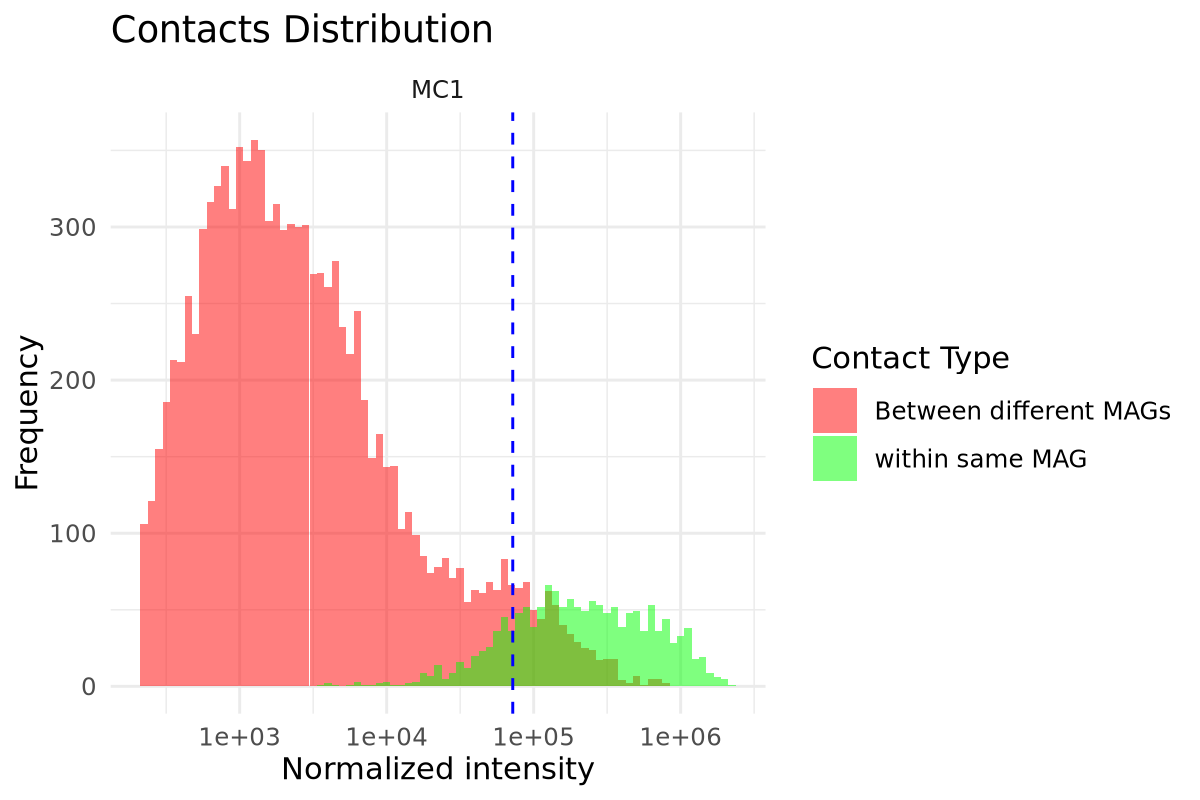

In [37]:
# Combine intra and inter contacts into a single data frame
combined_contacts <- bind_rows(mutate(intra_contacts, Contact_Type = "within same MAG"),
                               mutate(inter_contacts, Contact_Type = "Between different MAGs"))

# Create a data frame of thresholds
threshold_df <- data.frame(sample = names(threshold_list), threshold = unlist(threshold_list))

p.dims(6, 4)

# Plot combined histogram representing distribution of intensities for intra and inter species contacts changing x axis to logarithmic scale
ggplot(combined_contacts, aes(x = contacts, fill = Contact_Type)) +
  geom_histogram(binwidth = 0.05, alpha = 0.5, position = "identity") + 
  labs(title = "Contacts Distribution",
       x = "Normalized intensity",
       y = "Frequency") +
  scale_x_continuous(trans = 'log10') +
  facet_wrap(~ sample, scales = "free") +
  scale_fill_manual(values = c("within same MAG" = "green", "Between different MAGs" = "red"),
                    name = "Contact Type") +
  #xlim(-1, 20) +
  #geom_vline(data = threshold_df, aes(xintercept = 208), color = "blue", linetype = "dashed") +
  geom_vline(data = threshold_df, aes(xintercept = threshold), color = "blue", linetype = "dashed") +
  theme_minimal() 

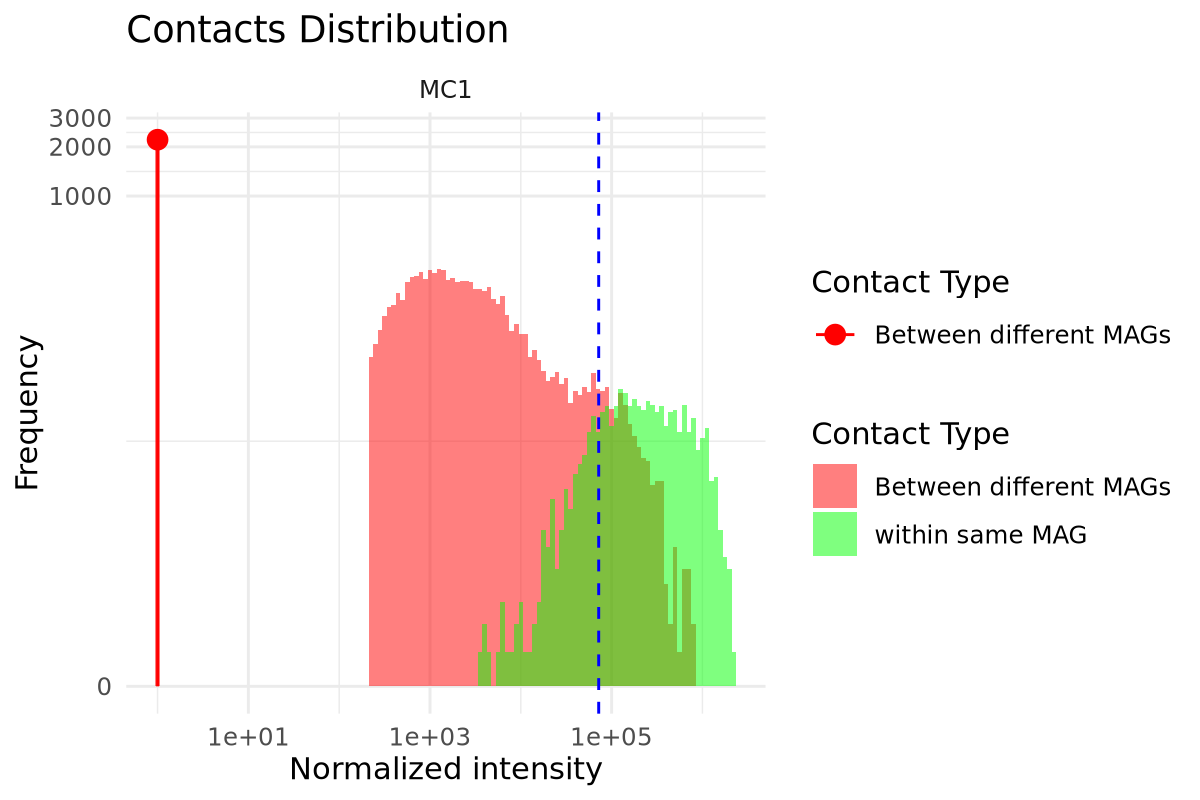

In [38]:
lollipop_data <- combined_contacts %>%
  mutate(contacts_shifted = contacts + 1,
         binned_contacts = floor(contacts_shifted / 0.1) * 0.1) %>%  # Apply binning
  group_by(Contact_Type, binned_contacts) %>%
  summarise(freq = n(), .groups = "drop")  # Count occurrences
# Separate data
zero_freq_data <- lollipop_data %>% filter(binned_contacts == 1)
#nonzero_freq_data <- lollipop_data %>% filter(binned_contacts > 1)

ggplot() +
  # Histogram for non-zero values
  geom_histogram(data = combined_contacts, aes(x = contacts + 1, fill = Contact_Type),
                 binwidth = 0.05, alpha = 0.5, position = "identity") +
  # Lollipop-style representation for zero values
  geom_segment(data = zero_freq_data, aes(x = binned_contacts, xend = binned_contacts, 
                                          y = 0, yend = freq, color = Contact_Type), linewidth = 0.5) +
  geom_point(data = zero_freq_data, aes(x = binned_contacts, y = freq, color = Contact_Type), size = 3) +
  # Axes and labels
  scale_x_continuous(trans = "log10") +
  scale_y_continuous(trans = pseudo_log_trans(base = 10)) +
  labs(title = "Contacts Distribution",
       x = "Normalized intensity",
       y = "Frequency") +
  # Facet by sample
  facet_wrap(~ sample, scales = "free") +
  # Colors
  scale_fill_manual(values = c("within same MAG" = "green", "Between different MAGs" = "red"),
                    name = "Contact Type") +
  scale_color_manual(values = c("within same MAG" = "green", "Between different MAGs" = "red"),
                     name = "Contact Type") +
  # Threshold line
  #geom_vline(data = threshold_df, aes(xintercept = 208), color = "blue", linetype = "dashed") +
  geom_vline(data = threshold_df, aes(xintercept = threshold + 1), color = "blue", linetype = "dashed") +
  theme_minimal()